# N1 · 从默认图到出版级图 + 方法示意图 (Publication-Quality Plot)

> 配套 9.6-L1/L2/L3 · **真实科研动作**: 拿 9.4 的交互效应数据, 从「默认 matplotlib 图」
> 一步步升级到「出版级」(before/after 对比), 导出矢量 PDF; 再画一张可复现的 pipeline 方法图。

一份数据走完「设计(9.4) → 留痕(9.5) → 出图(9.6)」全生命周期。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
EXP_SRC = Path.cwd().parent.parent / "experiment-design" / "src"   # 复用 9.4 实验数据
for p in (SRC, EXP_SRC):
    sys.path.insert(0, str(p))
import numpy as np
import matplotlib.pyplot as plt
import experiment as ex          # 9.4 模拟器
import plotstyle as ps           # 本专题出版级样式包
import schematic as sc

# 准备 9.4 的数据: 每个 (method,noise) 的 mean / sem
runs = ex.ablation_grid(seeds=range(8))
def stats(m, nz):
    xs = np.array(ex.runs_for(runs, method=m, noise=nz))
    return xs.mean(), xs.std(ddof=1)/np.sqrt(len(xs))
means = {m: [stats(m, nz)[0] for nz in ex.NOISES] for m in ex.METHODS}
sems  = {m: [stats(m, nz)[1] for nz in ex.NOISES] for m in ex.METHODS}
print("数据就绪:", {m: [round(v,3) for v in means[m]] for m in ex.METHODS})

数据就绪: {'DPO': [np.float64(0.619), np.float64(0.501), np.float64(0.397)], 'Robust-DPO': [np.float64(0.615), np.float64(0.591), np.float64(0.548)]}


## 1. BEFORE: 默认 matplotlib 图 (能看, 但不能印)

注意它的毛病: 有上/右边框、字偏小、无误差棒、默认配色不一定色盲安全。

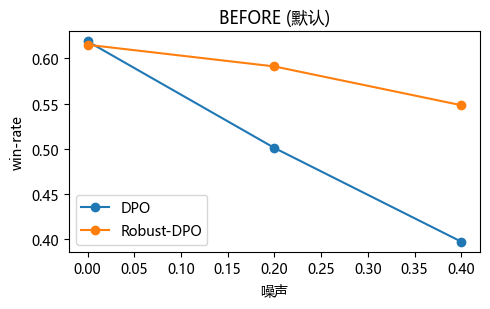

In [2]:
# 先恢复 matplotlib 默认风格作对照
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["axes.unicode_minus"] = False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: mpl.rcParams['font.sans-serif']=[f]; break
    except Exception: pass

fig, ax = plt.subplots(figsize=(5,3.2))
for m in ex.METHODS:
    ax.plot(ex.NOISES, means[m], marker="o", label=m)   # 无误差棒, 默认样式
ax.set_xlabel("噪声"); ax.set_ylabel("win-rate"); ax.set_title("BEFORE (默认)")
ax.legend()
plt.tight_layout(); plt.show()

## 2. AFTER: 出版级 (set_pub_style + 误差棒 + 去 chartjunk + 矢量导出)

一行 `set_pub_style()` 就改好字号/线宽/去边框/色盲色环; 加误差棒让它诚实 (9.4-L5)。

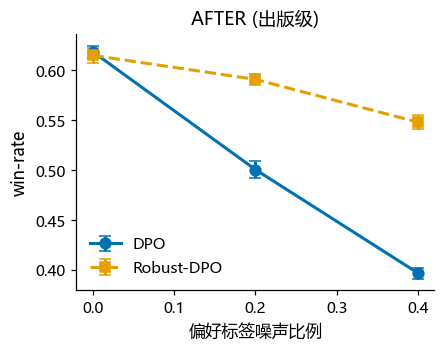

已导出: ['interaction_pub.pdf', 'interaction_pub.png'] (PDF 是矢量, 投稿用)


In [3]:
ps.set_pub_style()
fig, ax = plt.subplots(figsize=ps.column_figsize(width_in=4.2))
for m, mk in zip(ex.METHODS, ["o-", "s--"]):
    ax.errorbar(ex.NOISES, means[m], yerr=sems[m], fmt=mk, capsize=4, label=m)
ax.set_xlabel("偏好标签噪声比例"); ax.set_ylabel("win-rate")
ax.set_title("AFTER (出版级)")
ax.legend(frameon=False)
out = Path.cwd() / "_fig_output"
paths = ps.save_figure(fig, "interaction_pub", out_dir=out)   # 出 PDF + PNG
plt.show()
print("已导出:", [p.name for p in paths], "(PDF 是矢量, 投稿用)")

**对比**: AFTER 版字号更大 (缩小后仍清晰)、去掉上右边框 (data-ink↑)、带误差棒 (诚实)、
色盲安全配色、导出了矢量 PDF。两线张开 = 交互效应一眼可见 (一图一信息, L1)。

## 3. 分组柱状图: 用 plotstyle.grouped_bar (一行出带误差棒的标准对比图)

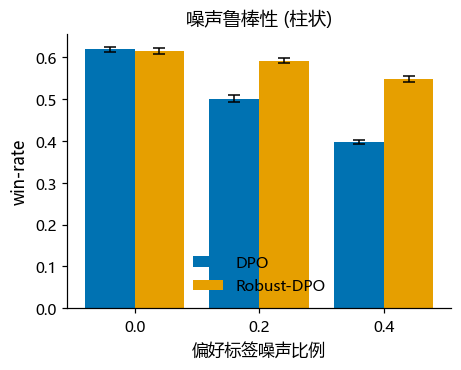

In [4]:
fig, ax = plt.subplots(figsize=ps.column_figsize(width_in=4.5))
ps.grouped_bar(
    ax,
    groups=[f"{nz}" for nz in ex.NOISES],
    series=ex.METHODS,
    means=[means[m] for m in ex.METHODS],
    errs=[sems[m] for m in ex.METHODS],
    ylabel="win-rate", title="噪声鲁棒性 (柱状)",
)
ax.set_xlabel("偏好标签噪声比例")
plt.show()

## 4. 方法示意图: pipeline 也能代码化 (L3, schematic.py)

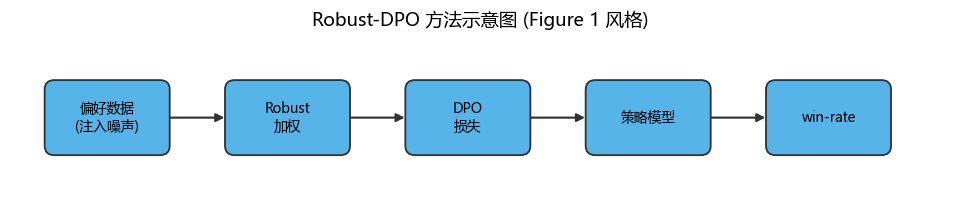

简单 pipeline 用代码画的好处: 可复现、进 git、改一个框不用重画整张 (9.5)。


In [5]:
fig, ax = plt.subplots(figsize=(11, 1.8))
sc.draw_pipeline(
    ax,
    ["偏好数据\n(注入噪声)", "Robust\n加权", "DPO\n损失", "策略模型", "win-rate"],
    title="Robust-DPO 方法示意图 (Figure 1 风格)",
    box_color="#56B4E9",
)
plt.show()
print("简单 pipeline 用代码画的好处: 可复现、进 git、改一个框不用重画整张 (9.5)。")

## 5. 反思

你刚把同一份数据从「默认能看」升级到「出版级能印」, 并画了一张方法图。带走:
1. `set_pub_style()` 一行解决 80% 的出版级规范 —— 这个包写真论文直接用。
2. 任何均值图都加误差棒 + 矢量 PDF 导出。
3. 简单 pipeline 可代码化 (可复现); 复杂架构图仍用 draw.io/TikZ。

下一步: 去 N2 看「同一份数据怎么被截断 y 轴骗人」, 守住图的诚实底线。